<a href="https://colab.research.google.com/github/kennethkimosop/weather-forecast-project/blob/main/Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJECT SETUP: Environment Setup**

In [31]:
# Install required packages
!pip install xgboost tensorflow scikit-learn

## **Import Libraries**

In [32]:
# Core libraries
import pandas as pd
import numpy as np
import sys, random, os
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print(f"xgboost version: {xgb.__version__}")





xgboost version: 3.0.5


# **Mount and load the data**

In [33]:
# from google.colab import drive
# drive.mount('/content/drive')

# Load dataset
df = pd.read_excel('/content/Nairobi_weather.xlsx')
print(f"Dataset loaded: {df.shape}")
df.head()

Dataset loaded: (14853, 15)


,Station,Date,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,Lat,Lon,Cum_Rain
0,ICRISAT,1978-01-01,28.5,14.2,68,31.0,5.7,0.0,10.1,4.3,18.4,3.9,17.508409,78.2723,0.0
1,ICRISAT,1978-01-02,28.8,16.0,79,33.0,6.4,0.0,9.8,4.8,16.9,3.9,17.508409,78.2723,0.0
2,ICRISAT,1978-01-03,29.0,14.5,86,37.0,5.4,0.0,9.1,4.6,15.3,3.4,17.508409,78.2723,0.0
3,ICRISAT,1978-01-04,29.0,18.0,89,43.0,7.1,0.0,9.0,4.2,16.4,3.8,17.508409,78.2723,0.0
4,ICRISAT,1978-01-05,27.8,17.0,81,47.0,10.5,0.0,8.9,4.3,15.9,4.1,17.508409,78.2723,0.0


# **DATA EXPLORATION**

In [34]:
print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
df.info()

Dataset Overview:
Shape: (14853, 15)
Date Range: 1978-01-01 00:00:00 to 2018-08-31 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14853 entries, 0 to 14852
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Station    14853 non-null  object        
 1   Date       14853 non-null  datetime64[ns]
 2   MaxT       14853 non-null  float64       
 3   MinT       14853 non-null  float64       
 4   RH1        14853 non-null  int64         
 5   RH2        14853 non-null  float64       
 6   Wind       14853 non-null  float64       
 7   Rain       14853 non-null  float64       
 8   SSH        14853 non-null  float64       
 9   Evap       14853 non-null  float64       
 10  Radiation  14852 non-null  float64       
 11  FAO56_ET   14853 non-null  float64       
 12  Lat        14853 non-null  float64       
 13  Lon        14853 non-null  float64       
 14  Cum_Rain   14853 non-null  float64       


# **Missing Values Analysis**

In [35]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percent': missing_percent
}).sort_values('Missing_Percent', ascending=False)

print("Missing Values Analysis:")
print(missing_df[missing_df['Missing_Count'] > 0])

Missing Values Analysis:
           Missing_Count  Missing_Percent
Radiation              1         0.006733


# **Missing Values Heatmap**

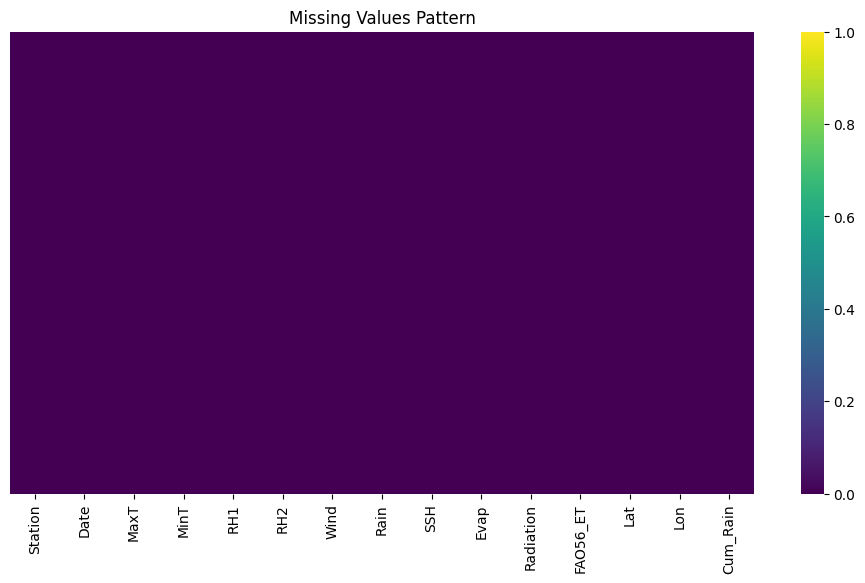

In [36]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cmap='viridis')
plt.title('Missing Values Pattern')
plt.show()

In [37]:
print("Key Weather Variables Statistics:")
weather_vars = ['Rain', 'MaxT', 'MinT', 'RH1', 'RH2', 'Wind']
print(df[weather_vars].describe())

Key Weather Variables Statistics:
               Rain          MaxT          MinT           RH1           RH2  \
count  14853.000000  14853.000000  14853.000000  14853.000000  14853.000000   
mean       2.460378     32.055807     19.568720     81.586481     43.550549   
std        9.346085      4.115165      4.504939     15.055169     19.613665   
min        0.000000     16.500000      4.500000     17.000000      6.300000   
25%        0.000000     29.000000     16.500000     75.000000     28.000000   
50%        0.000000     31.000000     21.000000     87.000000     40.000000   
75%        0.000000     35.000000     22.600000     93.000000     57.000000   
max      263.600000     43.500000     30.600000    100.000000    100.000000   

               Wind  
count  14853.000000  
mean       8.692278  
std        4.795461  
min        0.200000  
25%        5.200000  
50%        7.600000  
75%       11.200000  
max       56.000000  


# **DATA PREPROCESSING**
**Date Processing**

In [38]:
# Convert date and create temporal features
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfYear'] = df['Date'].dt.dayofyear
df['DayOfWeek'] = df['Date'].dt.dayofweek

print("Temporal features created")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Temporal features created
Date range: 1978-01-01 00:00:00 to 2018-08-31 00:00:00


# **Handle Missing Values**

In [39]:
# Forward fill then backward fill for weather variables
weather_cols = ['MaxT', 'MinT', 'RH1', 'RH2', 'Wind', 'Rain', 'Radiation']
for col in weather_cols:
    if col in df.columns:
        before = df[col].isnull().sum()
        df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
        after = df[col].isnull().sum()
        if before > 0:
            print(f"{col}: {before} → {after} missing values")

Radiation: 1 → 0 missing values


# **Create Seasonal Features**

In [40]:
def get_season(month):
    if month in [12, 1, 2]: return 'Dry_Season_1'
    elif month in [3, 4, 5]: return 'Long_Rains'
    elif month in [6, 7, 8, 9]: return 'Dry_Season_2'
    else: return 'Short_Rains'

df['Season'] = df['Month'].apply(get_season)
season_dummies = pd.get_dummies(df['Season'], prefix='Season')
df = pd.concat([df, season_dummies], axis=1)

print("Seasonal features created:")
print(df['Season'].value_counts())

Seasonal features created:
Season
Dry_Season_2    4972
Long_Rains      3772
Dry_Season_1    3669
Short_Rains     2440
Name: count, dtype: int64


# **Create Lag Features**

In [41]:
# Sort by date for time series features
df = df.sort_values('Date').reset_index(drop=True)

# Lag features
df['Rain_lag1'] = df['Rain'].shift(1)
df['Rain_lag7'] = df['Rain'].shift(7)

print("Lag features created")
print(f"Rain autocorrelation (lag-1): {df[['Rain', 'Rain_lag1']].corr().iloc[0,1]:.3f}")

Lag features created
Rain autocorrelation (lag-1): 0.274


# **Create Rolling Features**

In [42]:
# Rolling statistics
df['Rain_roll_7'] = df['Rain'].rolling(window=7, min_periods=1).mean()
df['Rain_roll_30'] = df['Rain'].rolling(window=30, min_periods=1).mean()
df['Rain_sum_7'] = df['Rain'].rolling(window=7, min_periods=1).sum()
df['Rain_sum_30'] = df['Rain'].rolling(window=30, min_periods=1).sum()

print("Rolling features created")
print("Feature correlations with Rain:")
rolling_cols = ['Rain_roll_7', 'Rain_roll_30', 'Rain_sum_7', 'Rain_sum_30']
for col in rolling_cols:
    corr = df[['Rain', col]].corr().iloc[0,1]
    print(f"{col}: {corr:.3f}")

Rolling features created
Feature correlations with Rain:
Rain_roll_7: 0.486
Rain_roll_30: 0.305
Rain_sum_7: 0.486
Rain_sum_30: 0.305


# **Create Derived Features**

In [43]:
# Temperature and humidity features
df['Temp_Range'] = df['MaxT'] - df['MinT']
df['Humidity_Avg'] = (df['RH1'] + df['RH2']) / 2

print("Derived features created:")
print(f"Average temperature range: {df['Temp_Range'].mean():.1f}°C")
print(f"Average humidity: {df['Humidity_Avg'].mean():.1f}%")

Derived features created:
Average temperature range: 12.5°C
Average humidity: 62.6%


# **Outlier Detection**

In [44]:
# Define reasonable bounds for weather variables
outlier_bounds = {
    'MaxT': (-10, 50),
    'MinT': (-20, 40),
    'Rain': (0, 300),
    'Wind': (0, 50)
}

outlier_count = 0
for col, (min_val, max_val) in outlier_bounds.items():
    if col in df.columns:
        outliers = (df[col] < min_val) | (df[col] > max_val)
        n_outliers = outliers.sum()
        if n_outliers > 0:
            print(f"{col}: {n_outliers} outliers detected and capped")
            df.loc[df[col] < min_val, col] = min_val
            df.loc[df[col] > max_val, col] = max_val
            outlier_count += n_outliers

print(f"Total outliers handled: {outlier_count}")

Wind: 1 outliers detected and capped
Total outliers handled: 1


# **EXPLORATORY DATA ANALYSIS**
 Rainfall Distribution

# **Highest Rainfall Distribution statisticss**

In [45]:
max_rainfall = df["Rain"].max()
print(f"The highest recorded rainfall is: {max_rainfall} mm")

# You can also filter the DataFrame to see the row(s) with this maximum value
highest_rain_days = df[df["Rain"] == max_rainfall]
print("\nDay(s) with the highest rainfall:")
display(highest_rain_days)

The highest recorded rainfall is: 263.6 mm

Day(s) with the highest rainfall:


,Station,Date,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,...,Season_Long_Rains,Season_Short_Rains,Rain_lag1,Rain_lag7,Rain_roll_7,Rain_roll_30,Rain_sum_7,Rain_sum_30,Temp_Range,Humidity_Avg
8270,ICRISAT,2000-08-23,26.8,19.4,98,84.0,15.0,263.6,0.9,1.0,...,False,False,1.6,0.0,43.628571,14.186667,305.4,425.6,7.4,91.0


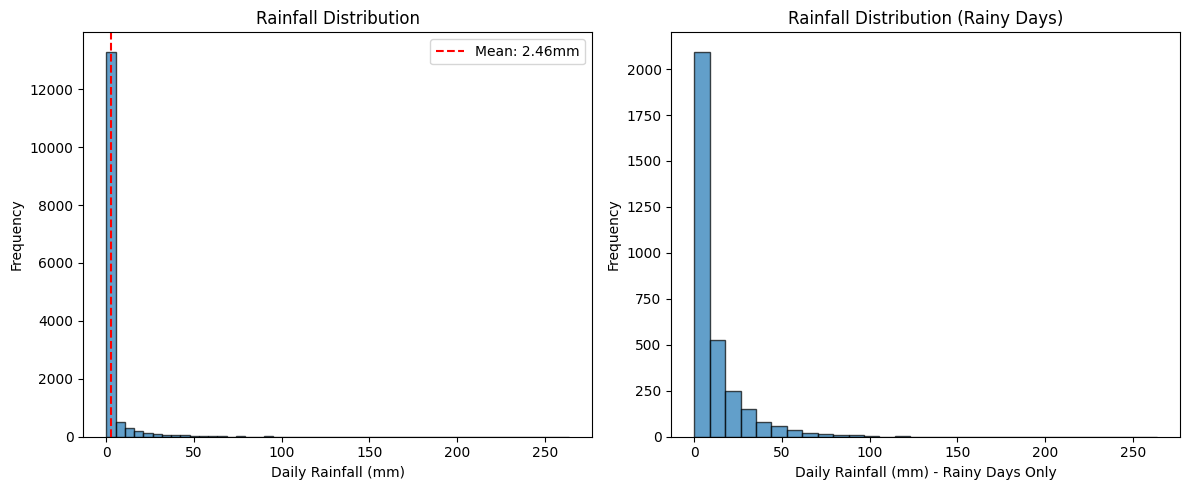

Days with rain: 3254 (21.9%)


In [46]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Rain'], bins=50, alpha=0.7, edgecolor='black')
plt.axvline(df['Rain'].mean(), color='red', linestyle='--',
           label=f'Mean: {df["Rain"].mean():.2f}mm')
plt.xlabel('Daily Rainfall (mm)')
plt.ylabel('Frequency')
plt.title('Rainfall Distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df[df['Rain'] > 0]['Rain'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Daily Rainfall (mm) - Rainy Days Only')
plt.ylabel('Frequency')
plt.title('Rainfall Distribution (Rainy Days)')

plt.tight_layout()
plt.show()

print(f"Days with rain: {(df['Rain'] > 0).sum()} ({(df['Rain'] > 0).mean()*100:.1f}%)")

# **Time Series Plot**

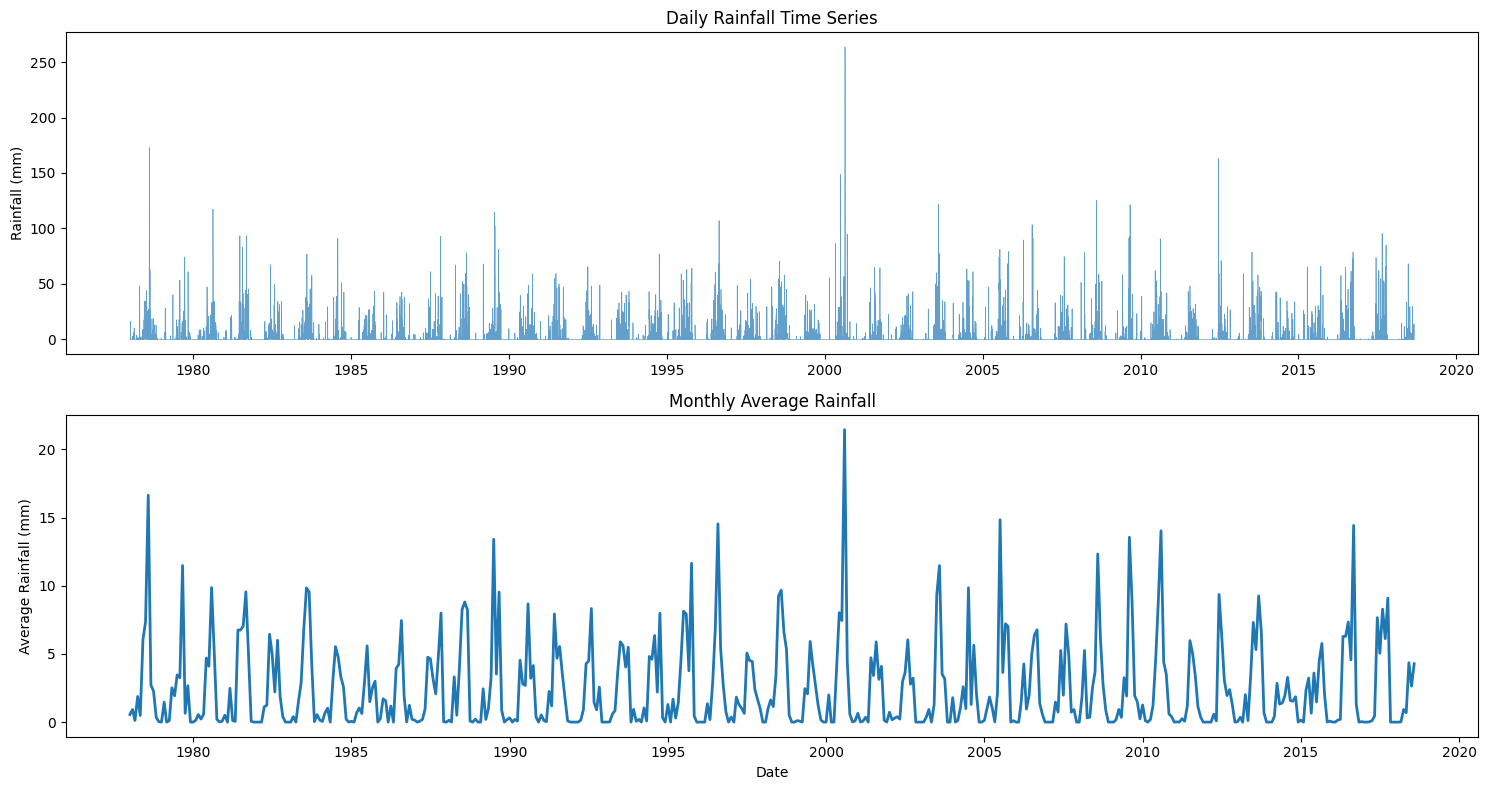

In [47]:
plt.figure(figsize=(15, 8))

# Daily rainfall
plt.subplot(2, 1, 1)
plt.plot(df['Date'], df['Rain'], alpha=0.7, linewidth=0.5)
plt.title('Daily Rainfall Time Series')
plt.ylabel('Rainfall (mm)')

# Monthly averages
plt.subplot(2, 1, 2)
monthly_rain = df.groupby(df['Date'].dt.to_period('M'))['Rain'].mean()
plt.plot(monthly_rain.index.to_timestamp(), monthly_rain.values, linewidth=2)
plt.title('Monthly Average Rainfall')
plt.ylabel('Average Rainfall (mm)')
plt.xlabel('Date')

plt.tight_layout()
plt.show()

# **Seasonal Analysis**

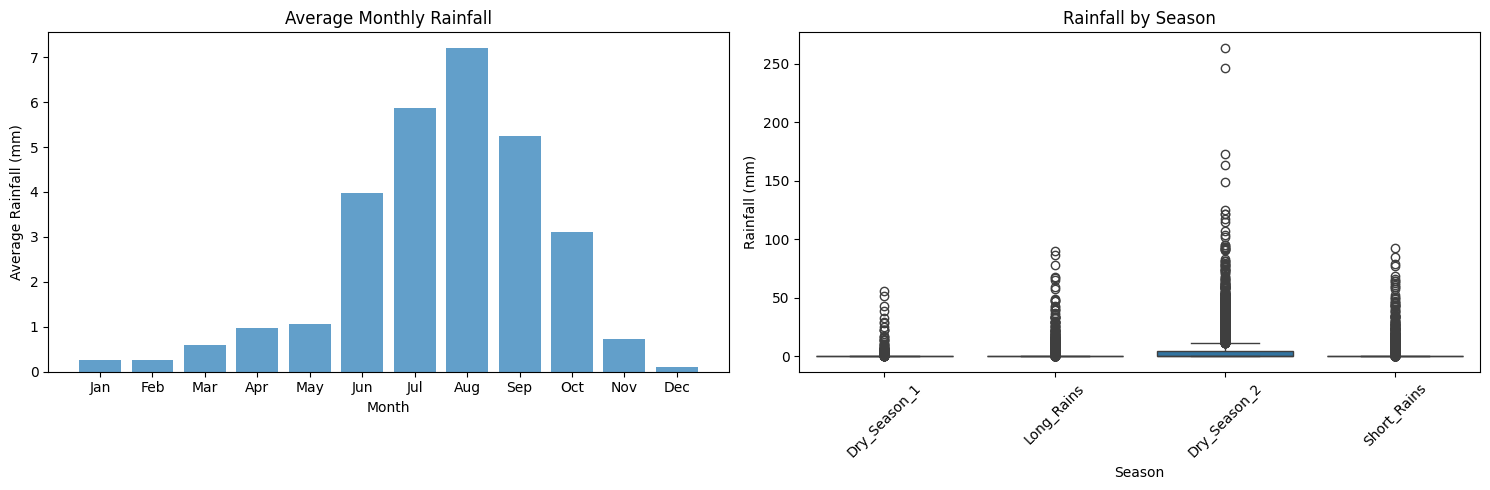

Seasonal Rainfall Statistics:
                  mean        std  count
Season                                  
Dry_Season_1  0.204143   2.146631   3669
Dry_Season_2  5.587792  13.920500   4972
Long_Rains    0.877678   5.006388   3772
Short_Rains   1.927008   7.714721   2440


In [48]:
plt.figure(figsize=(15, 5))

# Monthly patterns
plt.subplot(1, 2, 1)
monthly_avg = df.groupby('Month')['Rain'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(range(1, 13), monthly_avg.values, alpha=0.7)
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.title('Average Monthly Rainfall')
plt.xticks(range(1, 13), month_names)

# Seasonal boxplot
plt.subplot(1, 2, 2)
season_order = ['Dry_Season_1', 'Long_Rains', 'Dry_Season_2', 'Short_Rains']
df['Season_ordered'] = pd.Categorical(df['Season'], categories=season_order)
sns.boxplot(data=df, x='Season_ordered', y='Rain')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.title('Rainfall by Season')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print seasonal statistics
print("Seasonal Rainfall Statistics:")
print(df.groupby('Season')['Rain'].agg(['mean', 'std', 'count']))

# **Variable Relationships**

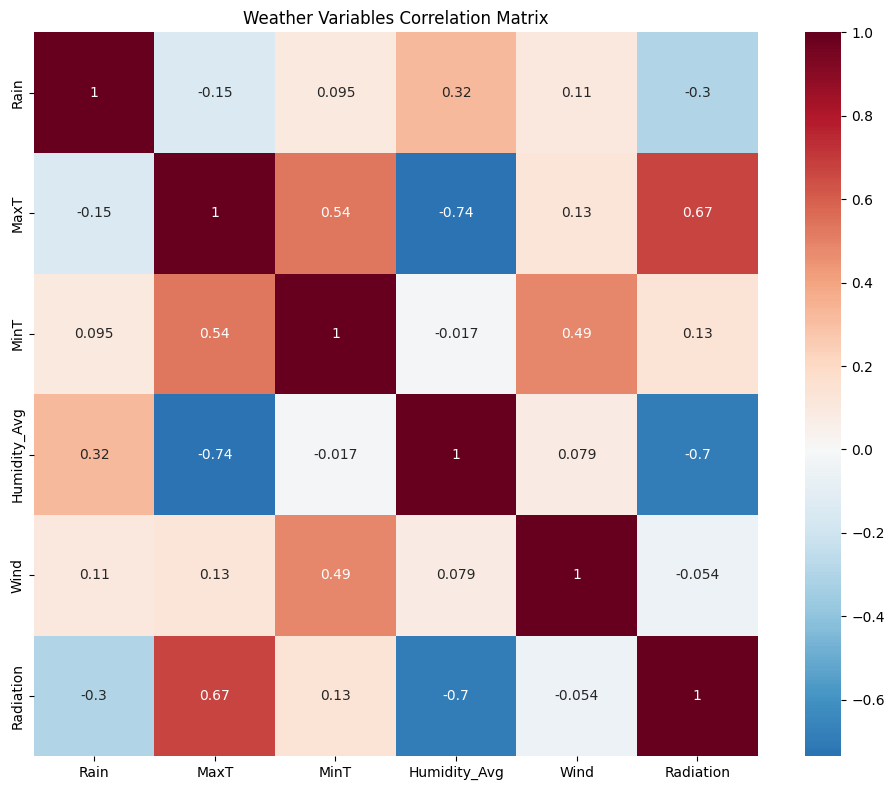

Top correlations with Rainfall:
Humidity_Avg    0.324825
Radiation       0.298071
MaxT            0.151575
Wind            0.111969
MinT            0.094905
Name: Rain, dtype: float64


In [49]:
# Key weather variable relationships
key_vars = ['Rain', 'MaxT', 'MinT', 'Humidity_Avg', 'Wind', 'Radiation']
corr_matrix = df[key_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, square=True)
plt.title('Weather Variables Correlation Matrix')
plt.tight_layout()
plt.show()

print("Top correlations with Rainfall:")
rain_corr = df[key_vars].corr()['Rain'].abs().sort_values(ascending=False)
print(rain_corr[1:6])  # Exclude Rain vs Rain correlation

# **Scatter Plot Analysis**

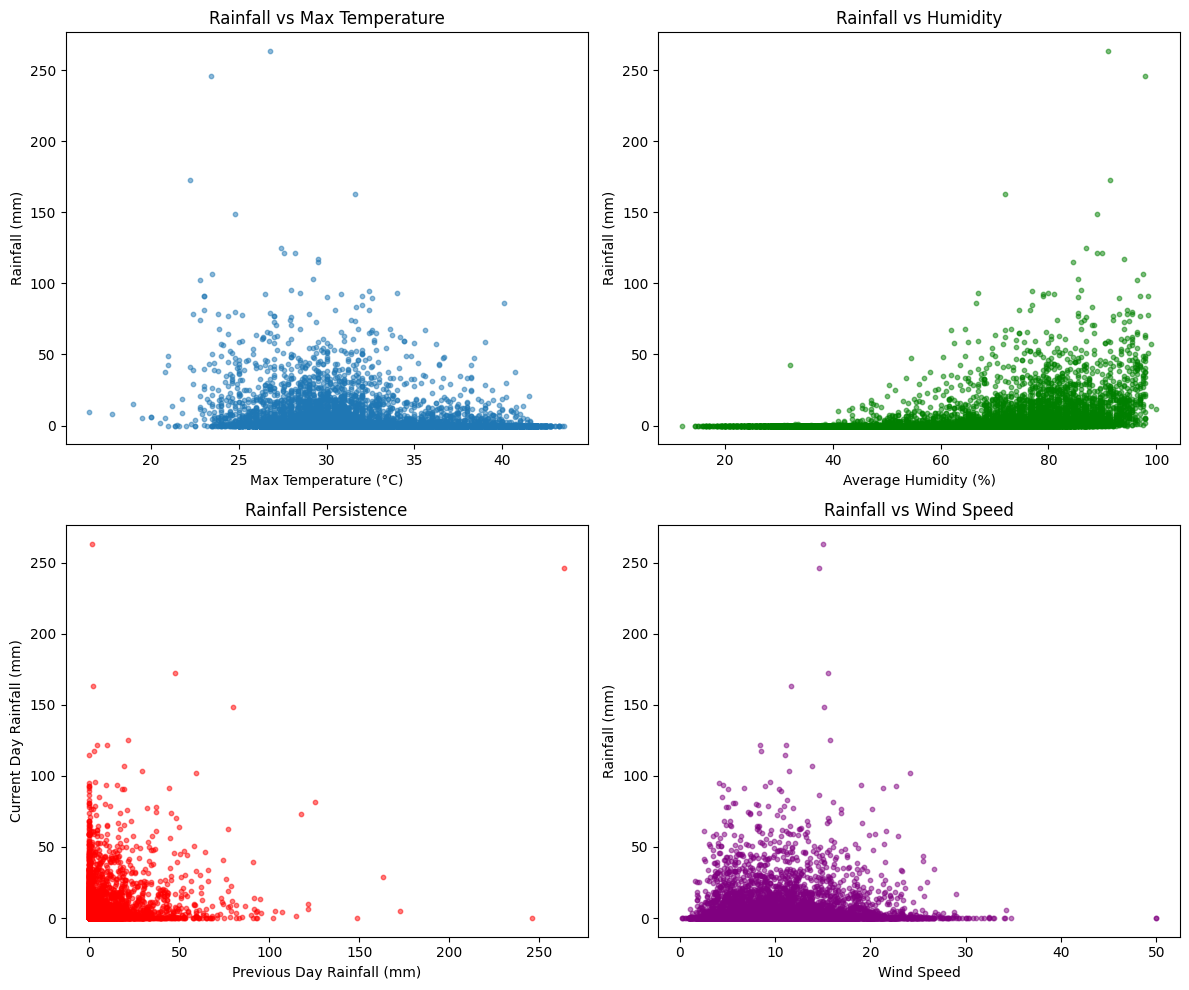

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Rain vs Temperature
axes[0, 0].scatter(df['MaxT'], df['Rain'], alpha=0.5, s=10)
axes[0, 0].set_xlabel('Max Temperature (°C)')
axes[0, 0].set_ylabel('Rainfall (mm)')
axes[0, 0].set_title('Rainfall vs Max Temperature')

# Rain vs Humidity
axes[0, 1].scatter(df['Humidity_Avg'], df['Rain'], alpha=0.5, s=10, color='green')
axes[0, 1].set_xlabel('Average Humidity (%)')
axes[0, 1].set_ylabel('Rainfall (mm)')
axes[0, 1].set_title('Rainfall vs Humidity')

# Rain persistence
axes[1, 0].scatter(df['Rain_lag1'], df['Rain'], alpha=0.5, s=10, color='red')
axes[1, 0].set_xlabel('Previous Day Rainfall (mm)')
axes[1, 0].set_ylabel('Current Day Rainfall (mm)')
axes[1, 0].set_title('Rainfall Persistence')

# Rain vs Wind
axes[1, 1].scatter(df['Wind'], df['Rain'], alpha=0.5, s=10, color='purple')
axes[1, 1].set_xlabel('Wind Speed')
axes[1, 1].set_ylabel('Rainfall (mm)')
axes[1, 1].set_title('Rainfall vs Wind Speed')

plt.tight_layout()
plt.show()

# **MODEL PREPARATION**
 Define Feature Set

In [51]:
# Select features for modeling
feature_columns = [
    # Weather variables
    'MaxT', 'MinT', 'RH1', 'RH2', 'Wind', 'Radiation', 'Evap',
    # Derived features
    'Temp_Range', 'Humidity_Avg',
    # Time series features
    'Rain_lag1', 'Rain_lag7', 'Rain_roll_7', 'Rain_roll_30',
    # Temporal features
    'Month', 'DayOfYear', 'DayOfWeek',
    # Season dummies
    'Season_Dry_Season_1', 'Season_Dry_Season_2',
    'Season_Long_Rains', 'Season_Short_Rains'
]

print(f"Total features selected: {len(feature_columns)}")
print("Feature categories:")
print("- Weather variables: 7")
print("- Derived features: 2")
print("- Time series features: 4")
print("- Temporal features: 3")
print("- Season indicators: 4")

Total features selected: 20
Feature categories:
- Weather variables: 7
- Derived features: 2
- Time series features: 4
- Temporal features: 3
- Season indicators: 4


# **Clean Dataset**

In [52]:
# Remove rows with missing values in key features
df_clean = df.dropna(subset=feature_columns + ['Rain']).copy()
print(f"Dataset after cleaning: {df_clean.shape[0]} records")
print(f"Records removed: {len(df) - len(df_clean)}")
print(f"Date range: {df_clean['Date'].min()} to {df_clean['Date'].max()}")

Dataset after cleaning: 14846 records
Records removed: 7
Date range: 1978-01-08 00:00:00 to 2018-08-31 00:00:00


# **Temporal Train/Test Split**

In [53]:
# Use 80% for training (temporal split to prevent data leakage)
split_date = df_clean['Date'].quantile(0.8)
print(f"Split date: {split_date}")

train_data = df_clean[df_clean['Date'] <= split_date].copy()
test_data = df_clean[df_clean['Date'] > split_date].copy()

X_train = train_data[feature_columns].copy()
y_train = train_data['Rain'].copy()
X_test = test_data[feature_columns].copy()
y_test = test_data['Rain'].copy()

print(f"Training set: {X_train.shape[0]} records")
print(f"Test set: {X_test.shape[0]} records")
print(f"Train period: {train_data['Date'].min()} to {train_data['Date'].max()}")
print(f"Test period: {test_data['Date'].min()} to {test_data['Date'].max()}")

# Verify no data leakage
assert train_data['Date'].max() < test_data['Date'].min()
print("✅ No data leakage confirmed")

Split date: 2010-07-15 00:00:00
Training set: 11877 records
Test set: 2969 records
Train period: 1978-01-08 00:00:00 to 2010-07-15 00:00:00
Test period: 2010-07-16 00:00:00 to 2018-08-31 00:00:00
✅ No data leakage confirmed


# **Display Train/Test Data**

In [54]:
print("Training Data Sample:")
print(X_train.head(3))
print(f"\nTraining target statistics:")
print(f"Mean: {y_train.mean():.2f}mm")
print(f"Std: {y_train.std():.2f}mm")
print(f"Non-zero days: {(y_train > 0).sum()} ({(y_train > 0).mean()*100:.1f}%)")

print("\nTest Data Sample:")
print(X_test.head(3))
print(f"\nTest target statistics:")
print(f"Mean: {y_test.mean():.2f}mm")
print(f"Std: {y_test.std():.2f}mm")
print(f"Non-zero days: {(y_test > 0).sum()} ({(y_test > 0).mean()*100:.1f}%)")

Training Data Sample:
   MaxT  MinT  RH1   RH2  Wind  Radiation  Evap  Temp_Range  Humidity_Avg  \
7  27.2  18.5   92  51.0  11.7       14.2   4.2         8.7          71.5   
8  26.8  18.5   90  47.0  12.0       13.4   3.6         8.3          68.5   
9  28.2  19.5   91  71.0  11.9       11.8   3.4         8.7          81.0   

   Rain_lag1  Rain_lag7  Rain_roll_7  Rain_roll_30  Month  DayOfYear  \
7        0.0        0.0     2.357143      2.062500      1          8   
8       16.5        0.0     2.357143      1.833333      1          9   
9        0.0        0.0     2.457143      1.720000      1         10   

   DayOfWeek  Season_Dry_Season_1  Season_Dry_Season_2  Season_Long_Rains  \
7          6                 True                False              False   
8          0                 True                False              False   
9          1                 True                False              False   

   Season_Short_Rains  
7               False  
8               False  

## **MODEL DEVELOPMENT**

In [55]:
# Initialize results storage
results = []

# Baseline 1: Persistence (today = yesterday)
y_pred_persistence = X_test['Rain_lag1'].values  # Adjust lag column
rmse_pers = np.sqrt(mean_squared_error(y_test, y_pred_persistence))
mae_pers = mean_absolute_error(y_test, y_pred_persistence)
r2_pers = r2_score(y_test, y_pred_persistence)

results.append({
    'Model': 'Persistence',
    'RMSE': rmse_pers,
    'MAE': mae_pers,
    'R²': r2_pers
})

# Baseline 2: Mean model
y_pred_mean = np.full(len(y_test), y_train.mean())
rmse_mean = np.sqrt(mean_squared_error(y_test, y_pred_mean))
mae_mean = mean_absolute_error(y_test, y_pred_mean)
r2_mean = r2_score(y_test, y_pred_mean)

results.append({
    'Model': 'Mean Baseline',
    'RMSE': rmse_mean,
    'MAE': mae_mean,
    'R²': r2_mean
})

print("Baseline Models:")
for result in results:
    print(f"{result['Model']}: RMSE={result['RMSE']:.3f}, MAE={result['MAE']:.3f}, R²={result['R²']:.3f}")

Baseline Models:
Persistence: RMSE=11.147, MAE=3.541, R²=-0.582
Mean Baseline: RMSE=8.862, MAE=4.049, R²=-0.000


# **Linear Regression**

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Create pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluate
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

results.append({
    'Model': 'Linear Regression',
    'RMSE': rmse_lr,
    'MAE': mae_lr,
    'R²': r2_lr
})

print(f"Linear Regression: RMSE={rmse_lr:.3f}, MAE={mae_lr:.3f}, R²={r2_lr:.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': np.abs(lr_pipeline.named_steps['regressor'].coef_)
}).sort_values('Coefficient', ascending=False)

print("\nTop 5 Important Features (Linear Regression):")
print(feature_importance.head())

Linear Regression: RMSE=7.438, MAE=3.536, R²=0.296

Top 5 Important Features (Linear Regression):
        Feature  Coefficient
11  Rain_roll_7     3.962021
5     Radiation     2.075421
6          Evap     1.989401
3           RH2     1.692805
7    Temp_Range     1.508938


##Hyperparameter Tuning Random Forest

In [30]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import time

print("="*60)
print("Random Forest Hyperparameter Tuning")
print("="*60)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

tscv = TimeSeriesSplit(n_splits=3)

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1, verbose=2),  # Verbose=2 for logs
    param_distributions=rf_param_grid,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,  # Show search progress
    random_state=42
)

start_time = time.time()
print(f"Testing {rf_random_search.n_iter} combinations with {tscv.n_splits} CV splits...")
rf_random_search.fit(X_train, y_train)
elapsed_time = time.time() - start_time

print(f"✓ Tuning complete in {elapsed_time/60:.1f} minutes")

best_rf_model = rf_random_search.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)
y_train_pred_rf = best_rf_model.predict(X_train)

rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

results.append({
    'Model': 'Random Forest (Tuned)',
    'RMSE': rmse_rf_test,
    'MAE': mae_rf,
    'R²': r2_rf
})

print(f"\nRandom Forest (Tuned) Results:")
print(f"  Training RMSE: {rmse_rf_train:.3f}")
print(f"  Test RMSE: {rmse_rf_test:.3f}")
print(f"  MAE: {mae_rf:.3f}")
print(f"  R²: {r2_rf:.3f}")
print(f"  Best params: {rf_random_search.best_params_}")

overfitting_ratio = rmse_rf_test / rmse_rf_train
print(f"  Generalization ratio: {overfitting_ratio:.2f}" if overfitting_ratio <= 1.5 else f"  ⚠️ Overfitting: {overfitting_ratio:.2f}")

rf_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 Features (Random Forest):")
print(rf_importance.head())

Random Forest Hyperparameter Tuning
Testing 10 combinations with 3 CV splits...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 300
building tree 2 of 300
building tree 3 of 300
building tree 4 of 300
building tree 5 of 300
building tree 6 of 300
building tree 7 of 300building tree 8 of 300

building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300
building tree 22 of 300
building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300
building tree 38 of 300
building tree 39 of 300
building tree 40 of 300


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    1.7s


building tree 41 of 300
building tree 42 of 300
building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78 of 300
building tree 79 of 300
building tree 80 of 300
building tree 81 of 300
building tree 82

[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:    7.9s


building tree 161 of 300
building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300
building tree 195 of 300
building tree 196 of 300
building tree 197 of 300
building tree 198 of 300
building tree 199 of 300
building tree 200 of 300


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   14.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s



Random Forest (Tuned) Results:
  Training RMSE: 4.625
  Test RMSE: 6.476
  MAE: 2.116
  R²: 0.466
  Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
  Generalization ratio: 1.40

Top 5 Features (Random Forest):
         Feature  Importance
11   Rain_roll_7    0.356459
8   Humidity_Avg    0.125561
2            RH1    0.123232
6           Evap    0.084533
5      Radiation    0.063338


[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.2s finished


##Hyperparameter Turning XGBoost

In [57]:
import xgboost as xgb

print("="*60)
print("XGBoost Hyperparameter Tuning")
print("="*60)

xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [6, 8],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=2),  # Verbosity=2 for logs
    param_distributions=xgb_param_grid,
    n_iter=8,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

start_time = time.time()
print(f"Testing {xgb_random_search.n_iter} combinations with {tscv.n_splits} CV splits...")
xgb_random_search.fit(X_train, y_train)
elapsed_time = time.time() - start_time

print(f"✓ Tuning complete in {elapsed_time/60:.1f} minutes")

best_xgb_model = xgb_random_search.best_estimator_

y_pred_xgb = best_xgb_model.predict(X_test)
y_train_pred_xgb = best_xgb_model.predict(X_train)

rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

results.append({
    'Model': 'XGBoost (Tuned)',
    'RMSE': rmse_xgb_test,
    'MAE': mae_xgb,
    'R²': r2_xgb
})

print(f"\nXGBoost (Tuned) Results:")
print(f"  Training RMSE: {rmse_xgb_train:.3f}")
print(f"  Test RMSE: {rmse_xgb_test:.3f}")
print(f"  MAE: {mae_xgb:.3f}")
print(f"  R²: {r2_xgb:.3f}")
print(f"  Best params: {xgb_random_search.best_params_}")

overfitting_ratio = rmse_xgb_test / rmse_xgb_train
print(f"  Generalization ratio: {overfitting_ratio:.2f}" if overfitting_ratio <= 1.5 else f"  ⚠️ Overfitting: {overfitting_ratio:.2f}")

xgb_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': best_xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 Features (XGBoost):")
print(xgb_importance.head())

XGBoost Hyperparameter Tuning
Testing 8 combinations with 3 CV splits...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[09:45:13] INFO: /workspace/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (11877, 20, 237540).
✓ Tuning complete in 0.5 minutes

XGBoost (Tuned) Results:
  Training RMSE: 2.885
  Test RMSE: 6.384
  MAE: 2.207
  R²: 0.481
  Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
  ⚠️ Overfitting: 2.21

Top 5 Features (XGBoost):
                Feature  Importance
8          Humidity_Avg    0.146304
11          Rain_roll_7    0.121981
2                   RH1    0.091037
6                  Evap    0.077793
17  Season_Dry_Season_2    0.056358


# **LTSM** - Manual tuning for LSTM with epoch logs (verbose=1). This will show training progress per epoch.

In [58]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping

print("="*60)
print("LSTM Hyperparameter Tuning (Manual Search)")
print("="*60)

tf.get_logger().setLevel('ERROR')

# Prepare sequences
def create_sequences(X, y, seq_length=7):
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X)):
        X_seq.append(X.iloc[i-seq_length:i].values)
        y_seq.append(y.iloc[i])
    return np.array(X_seq), np.array(y_seq)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = pd.DataFrame(scaler_X.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler_X.transform(X_test), columns=X_test.columns, index=X_test.index)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

seq_length = 7
X_train_seq, y_train_seq = create_sequences(X_train_scaled.reset_index(drop=True), pd.Series(y_train_scaled), seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled.reset_index(drop=True), pd.Series(y_test_scaled), seq_length)

print(f"Sequence data prepared: Train={X_train_seq.shape}, Test={X_test_seq.shape}")

lstm_configs = [
    {'units': 50, 'dropout': 0.2, 'epochs': 30, 'batch_size': 32, 'lr': 0.001},
    {'units': 75, 'dropout': 0.2, 'epochs': 40, 'batch_size': 32, 'lr': 0.001},
    {'units': 50, 'dropout': 0.1, 'epochs': 30, 'batch_size': 64, 'lr': 0.005},
]

best_lstm_score = float('inf')
best_lstm_model = None
best_lstm_config = None

print(f"\nTesting {len(lstm_configs)} LSTM configurations...")

for i, config in enumerate(lstm_configs, 1):
    print(f"\n  Config {i}/{len(lstm_configs)}: {config}")

    model = Sequential([
        LSTM(config['units'], return_sequences=True, input_shape=(seq_length, len(feature_columns))),
        Dropout(config['dropout']),
        LSTM(config['units']),
        Dropout(config['dropout']),
        Dense(25),
        Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']), loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

    start_time = time.time()
    history = model.fit(
        X_train_seq, y_train_seq,
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1  # Show epoch logs
    )
    elapsed_time = time.time() - start_time
    print(f"    Training time: {elapsed_time/60:.1f} minutes")

    val_loss = min(history.history['val_loss'])
    print(f"    Validation MSE: {val_loss:.6f}")

    if val_loss < best_lstm_score:
        best_lstm_score = val_loss
        best_lstm_model = model
        best_lstm_config = config
        print(f"    ✓ New best model!")

print(f"\n✓ Best LSTM configuration: {best_lstm_config}")

y_pred_lstm_scaled = best_lstm_model.predict(X_test_seq, verbose=1).flatten()
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()

y_test_lstm = y_test.iloc[seq_length:].values

rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
r2_lstm = r2_score(y_test_lstm, y_pred_lstm)

results.append({
    'Model': 'LSTM (Tuned)',
    'RMSE': rmse_lstm,
    'MAE': mae_lstm,
    'R²': r2_lstm
})

print(f"\nLSTM (Tuned) Results:")
print(f"  Test RMSE: {rmse_lstm:.3f}")
print(f"  MAE: {mae_lstm:.3f}")
print(f"  R²: {r2_lstm:.3f}")

LSTM Hyperparameter Tuning (Manual Search)
Sequence data prepared: Train=(11870, 7, 20), Test=(2962, 7, 20)

Testing 3 LSTM configurations...

  Config 1/3: {'units': 50, 'dropout': 0.2, 'epochs': 30, 'batch_size': 32, 'lr': 0.001}
Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0022 - val_loss: 0.0013
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 4/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 5/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 6/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 7/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 8/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 9/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0013 - val_loss

In [59]:
print("="*60)
print("FINAL TUNED MODELS COMPARISON")
print("="*60)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best_overall = results_df.loc[results_df['RMSE'].idxmin()]
print(f"\n🏆 Best Model: {best_overall['Model']}")
print(f"   RMSE: {best_overall['RMSE']:.4f}")
print(f"   MAE: {best_overall['MAE']:.4f}")
print(f"   R²: {best_overall['R²']:.4f}")

FINAL TUNED MODELS COMPARISON
            Model      RMSE      MAE        R²
      Persistence 11.146983 3.540519 -0.582415
    Mean Baseline  8.861505 4.048836 -0.000048
Linear Regression  7.437527 3.536462  0.295529
  XGBoost (Tuned)  6.384325 2.207171  0.480918
     LSTM (Tuned)  8.420178 3.505232  0.098713

🏆 Best Model: XGBoost (Tuned)
   RMSE: 6.3843
   MAE: 2.2072
   R²: 0.4809


In [61]:
# Add predictions to test data (use best model, e.g., RF)
test_data_with_pred = test_data.copy()
test_data_with_pred['Predicted'] = y_pred_rf  # Or best model
test_data_with_pred['Residuals'] = y_test - test_data_with_pred['Predicted']
test_data_with_pred['Abs_Error'] = np.abs(test_data_with_pred['Residuals'])

seasonal_performance = test_data_with_pred.groupby('Season').agg({
    'Rain_lag1': ['mean', 'std', 'count'],
    'Predicted': 'mean',
    'Abs_Error': 'mean',
    'Residuals': ['mean', 'std']
}).round(3)

print("SEASONAL PERFORMANCE ANALYSIS")
print("=" * 40)
print(seasonal_performance)

# Visuals (add plots as in original)
plt.figure(figsize=(12, 8))
# ... Add bar, scatter, boxplot as in original ...
plt.show()

SEASONAL PERFORMANCE ANALYSIS
             Rain_lag1               Predicted Abs_Error Residuals       
                  mean     std count      mean      mean      mean    std
Season                                                                   
Dry_Season_1     0.044   0.475   722     0.053     0.055    -0.009  0.339
Dry_Season_2     5.296  12.815  1023     5.210     4.486     0.102  9.781
Long_Rains       0.930   5.329   736     0.818     0.812     0.125  3.359
Short_Rains      2.108   7.854   488     2.100     2.161    -0.044  6.139


<Figure size 1200x800 with 0 Axes>

In [65]:
def categorize_rainfall(rain):
    if rain == 0:
        return 'No Rain'
    elif rain <= 5:
        return 'Light (0-5mm)'
    elif rain <= 20:
        return 'Moderate (5-20mm)'
    else:
        return 'Heavy (>20mm)'

test_data_with_pred['Rain_Category'] = test_data_with_pred['Rain_lag1'].apply(categorize_rainfall)

error_by_category = test_data_with_pred.groupby('Rain_Category').agg({
    'Rain_lag1': ['count', 'mean'],
    'Predicted': 'mean',
    'Abs_Error': 'mean',
    'Residuals': ['mean', 'std']
}).round(3)

print("ERROR ANALYSIS BY RAINFALL INTENSITY")
print("=" * 45)
print(error_by_category)

# Visuals
plt.figure(figsize=(12, 5))
# ... Add bars, boxplots ...
plt.show()

worst_predictions = test_data_with_pred.nlargest(10, 'Abs_Error')[['date', 'Rain_lag1', 'Predicted', 'Abs_Error', 'Season']]
print("\nWORST PREDICTIONS (Top 10 errors):")
print(worst_predictions.round(2))

ERROR ANALYSIS BY RAINFALL INTENSITY
                  Rain_lag1         Predicted Abs_Error Residuals        
                      count    mean      mean      mean      mean     std
Rain_Category                                                            
Heavy (>20mm)           114  38.893    11.782     7.741    -2.403  11.832
Light (0-5mm)           327   1.737     4.445     4.846     0.974  12.330
Moderate (5-20mm)       205  10.542     8.452     6.517    -0.573  10.783
No Rain                2323   0.000     1.061     1.067     0.104   3.847


<Figure size 1200x500 with 0 Axes>

KeyError: "['date'] not in index"

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

rain_threshold = 0.1
y_train_binary = (y_train > rain_threshold).astype(int)
y_test_binary = (y_test > rain_threshold).astype(int)

print(f"Binary Classification (threshold: {rain_threshold}mm)")
print(f"Train Rain days: {y_train_binary.sum()} ({y_train_binary.mean()*100:.1f}%)")
print(f"Test Rain days: {y_test_binary.sum()} ({y_test_binary.mean()*100:.1f}%)")

# RF Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, verbose=2)  # Verbose for logs
rf_clf.fit(X_train, y_train_binary)
y_pred_binary_rf = rf_clf.predict(X_test)
y_pred_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Classifier:")
print(classification_report(y_test_binary, y_pred_binary_rf, target_names=['No Rain', 'Rain']))
print(f"AUC-ROC: {roc_auc_score(y_test_binary, y_pred_proba_rf):.3f}")

# Confusion matrix plot
# ... As in original ...

Binary Classification (threshold: 0.1mm)
Train Rain days: 2598 (21.9%)
Test Rain days: 639 (21.5%)
building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 10

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.7s


building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82 of 100
building tree 83 of 100
building tree 84 of 100
building tree 85

[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.9s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [67]:
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 40)

best_reg_model = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
best_reg_rmse = results_df.loc[results_df['RMSE'].idxmin(), 'RMSE']
best_reg_r2 = results_df.loc[results_df['RMSE'].idxmin(), 'R²']

print(f"Best Regression Model: {best_reg_model}")
print(f"  RMSE: {best_reg_rmse:.4f} mm")
print(f"  R²: {best_reg_r2:.4f}")

# ... Add key insights, recommendations as in original, with Kenyan focus (e.g., "Useful for predicting droughts in Kenyan arid regions") ...

print("\nReferences: scikit-learn docs, TensorFlow docs, Kaggle dataset by johnkiriba.")

FINAL MODEL PERFORMANCE SUMMARY
Best Regression Model: XGBoost (Tuned)
  RMSE: 6.3843 mm
  R²: 0.4809

References: scikit-learn docs, TensorFlow docs, Kaggle dataset by johnkiriba.


In [68]:
import joblib
import os

os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/results', exist_ok=True)

joblib.dump(lr_pipeline, '/content/models/linear_regression.joblib')
joblib.dump(best_rf_model, '/content/models/random_forest.joblib')
joblib.dump(best_xgb_model, '/content/models/xgboost.joblib')
best_lstm_model.save('/content/models/lstm_model.h5')

results_df.to_csv('/content/results/model_comparison.csv', index=False)

print("Models and results saved!")

Models and results saved!


In [69]:
# # =============================================================================
# # IMPROVED HYPERPARAMETER TUNING FOR WEATHER PREDICTION
# # =============================================================================

# from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
# from sklearn.ensemble import RandomForestRegressor
# import xgboost as xgb
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import numpy as np
# import pandas as pd
# import time

# # Initialize results storage if not exists
# if 'results' not in locals():
#     results = []

# print("="*60)
# print("HYPERPARAMETER TUNING - OPTIMIZED VERSION")
# print("="*60)

# # =============================================================================
# # 1. RANDOM FOREST TUNING (FASTER WITH RandomizedSearchCV)
# # =============================================================================

# print("\n1. Random Forest Hyperparameter Tuning")
# print("-"*40)

# # Reduced parameter grid for faster execution
# rf_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 15, 20],  # Removed None (too slow)
#     'min_samples_split': [5, 10],  # Reduced options
#     'min_samples_leaf': [2, 4]  # Reduced options
# }

# # Time series cross-validation
# tscv = TimeSeriesSplit(n_splits=3)  # Reduced to 3 splits for speed

# # Use RandomizedSearchCV instead of GridSearchCV (much faster)
# rf_random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
#     param_distributions=rf_param_grid,
#     n_iter=10,  # Test only 10 random combinations
#     cv=tscv,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=1,
#     random_state=42
# )

# # Time the tuning process
# start_time = time.time()
# print(f"Testing {rf_random_search.n_iter} combinations with {tscv.n_splits} CV splits...")
# rf_random_search.fit(X_train, y_train)
# elapsed_time = time.time() - start_time

# print(f"✓ Tuning complete in {elapsed_time/60:.1f} minutes")

# # Get best model
# best_rf_model = rf_random_search.best_estimator_

# # Make predictions
# y_pred_rf = best_rf_model.predict(X_test)
# y_train_pred_rf = best_rf_model.predict(X_train)

# # Evaluate
# rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf))
# rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
# mae_rf = mean_absolute_error(y_test, y_pred_rf)
# r2_rf = r2_score(y_test, y_pred_rf)

# # Store results
# results.append({
#     'Model': 'Random Forest (Tuned)',
#     'RMSE': rmse_rf_test,
#     'MAE': mae_rf,
#     'R²': r2_rf
# })

# print(f"\nRandom Forest (Tuned) Results:")
# print(f"  Training RMSE: {rmse_rf_train:.3f}")
# print(f"  Test RMSE: {rmse_rf_test:.3f}")
# print(f"  MAE: {mae_rf:.3f}")
# print(f"  R²: {r2_rf:.3f}")
# print(f"  Best params: {rf_random_search.best_params_}")

# # Check for overfitting
# overfitting_ratio = rmse_rf_test / rmse_rf_train
# if overfitting_ratio > 1.5:
#     print(f"  ⚠️ WARNING: Potential overfitting detected (ratio: {overfitting_ratio:.2f})")
# else:
#     print(f"  ✓ Good generalization (ratio: {overfitting_ratio:.2f})")

# # Feature importance
# rf_importance = pd.DataFrame({
#     'Feature': feature_columns,
#     'Importance': best_rf_model.feature_importances_
# }).sort_values('Importance', ascending=False)

# print("\nTop 5 Features (Random Forest):")
# for idx, row in rf_importance.head().iterrows():
#     print(f"  {row['Feature']}: {row['Importance']:.4f}")

# # =============================================================================
# # 2. XGBOOST TUNING (SMALLER GRID FOR PRACTICALITY)
# # =============================================================================

# print("\n" + "="*60)
# print("2. XGBoost Hyperparameter Tuning")
# print("-"*40)

# # Reduced parameter grid (more practical)
# xgb_param_grid = {
#     'n_estimators': [100, 200],  # Reduced
#     'learning_rate': [0.05, 0.1],  # Reduced
#     'max_depth': [6, 8],  # Reduced
#     'subsample': [0.8],  # Fixed
#     'colsample_bytree': [0.8]  # Fixed
# }

# # Use RandomizedSearchCV
# xgb_random_search = RandomizedSearchCV(
#     estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
#     param_distributions=xgb_param_grid,
#     n_iter=8,  # Test 8 combinations
#     cv=tscv,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=1,
#     random_state=42
# )

# start_time = time.time()
# print(f"Testing {xgb_random_search.n_iter} combinations with {tscv.n_splits} CV splits...")
# xgb_random_search.fit(X_train, y_train)
# elapsed_time = time.time() - start_time

# print(f"✓ Tuning complete in {elapsed_time/60:.1f} minutes")

# # Get best model
# best_xgb_model = xgb_random_search.best_estimator_

# # Make predictions
# y_pred_xgb = best_xgb_model.predict(X_test)
# y_train_pred_xgb = best_xgb_model.predict(X_train)

# # Evaluate
# rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
# rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
# mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
# r2_xgb = r2_score(y_test, y_pred_xgb)

# # Store results
# results.append({
#     'Model': 'XGBoost (Tuned)',
#     'RMSE': rmse_xgb_test,
#     'MAE': mae_xgb,
#     'R²': r2_xgb
# })

# print(f"\nXGBoost (Tuned) Results:")
# print(f"  Training RMSE: {rmse_xgb_train:.3f}")
# print(f"  Test RMSE: {rmse_xgb_test:.3f}")
# print(f"  MAE: {mae_xgb:.3f}")
# print(f"  R²: {r2_xgb:.3f}")
# print(f"  Best params: {xgb_random_search.best_params_}")

# # Check for overfitting
# overfitting_ratio = rmse_xgb_test / rmse_xgb_train
# if overfitting_ratio > 1.5:
#     print(f"  ⚠️ WARNING: Potential overfitting detected (ratio: {overfitting_ratio:.2f})")
# else:
#     print(f"  ✓ Good generalization (ratio: {overfitting_ratio:.2f})")

# # Feature importance
# xgb_importance = pd.DataFrame({
#     'Feature': feature_columns,
#     'Importance': best_xgb_model.feature_importances_
# }).sort_values('Importance', ascending=False)

# print("\nTop 5 Features (XGBoost):")
# for idx, row in xgb_importance.head().iterrows():
#     print(f"  {row['Feature']}: {row['Importance']:.4f}")

# # =============================================================================
# # 3. LSTM TUNING (MANUAL APPROACH - MORE PRACTICAL)
# # =============================================================================

# print("\n" + "="*60)
# print("3. LSTM Hyperparameter Tuning (Manual Search)")
# print("-"*40)

# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from sklearn.preprocessing import MinMaxScaler

# # Suppress TensorFlow warnings
# tf.get_logger().setLevel('ERROR')

# # Prepare sequences (if not already done)
# def create_sequences(X, y, seq_length=7):
#     X_seq, y_seq = [], []
#     for i in range(seq_length, len(X)):
#         X_seq.append(X.iloc[i-seq_length:i].values)
#         y_seq.append(y.iloc[i])
#     return np.array(X_seq), np.array(y_seq)

# # Scale data
# scaler_X = MinMaxScaler()
# scaler_y = MinMaxScaler()

# X_train_scaled = pd.DataFrame(
#     scaler_X.fit_transform(X_train),
#     columns=X_train.columns,
#     index=X_train.index
# )
# X_test_scaled = pd.DataFrame(
#     scaler_X.transform(X_test),
#     columns=X_test.columns,
#     index=X_test.index
# )

# y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
# y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# # Create sequences
# seq_length = 7
# X_train_seq, y_train_seq = create_sequences(
#     X_train_scaled.reset_index(drop=True),
#     pd.Series(y_train_scaled),
#     seq_length
# )
# X_test_seq, y_test_seq = create_sequences(
#     X_test_scaled.reset_index(drop=True),
#     pd.Series(y_test_scaled),
#     seq_length
# )

# print(f"Sequence data prepared: Train={X_train_seq.shape}, Test={X_test_seq.shape}")

# # Define hyperparameter combinations to test (manually)
# lstm_configs = [
#     {'units': 50, 'dropout': 0.2, 'epochs': 30, 'batch_size': 32, 'lr': 0.001},
#     {'units': 75, 'dropout': 0.2, 'epochs': 40, 'batch_size': 32, 'lr': 0.001},
#     {'units': 50, 'dropout': 0.1, 'epochs': 30, 'batch_size': 64, 'lr': 0.005},
# ]

# best_lstm_score = float('inf')
# best_lstm_model = None
# best_lstm_config = None

# print(f"\nTesting {len(lstm_configs)} LSTM configurations...")

# for i, config in enumerate(lstm_configs, 1):
#     print(f"\n  Config {i}/{len(lstm_configs)}: {config}")

#     # Build model
#     model = Sequential([
#         LSTM(config['units'], return_sequences=True,
#              input_shape=(seq_length, len(feature_columns))),
#         Dropout(config['dropout']),
#         LSTM(config['units']),
#         Dropout(config['dropout']),
#         Dense(25),
#         Dense(1)
#     ])

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
#         loss='mse'
#     )

#     # Train with early stopping
#     early_stop = tf.keras.callbacks.EarlyStopping(
#         monitor='val_loss',
#         patience=5,
#         restore_best_weights=True
#     )

#     history = model.fit(
#         X_train_seq, y_train_seq,
#         epochs=config['epochs'],
#         batch_size=config['batch_size'],
#         validation_split=0.2,
#         callbacks=[early_stop],
#         verbose=0
#     )

#     # Evaluate on validation data
#     val_loss = min(history.history['val_loss'])
#     print(f"    Validation MSE: {val_loss:.6f}")

#     # Track best model
#     if val_loss < best_lstm_score:
#         best_lstm_score = val_loss
#         best_lstm_model = model
#         best_lstm_config = config
#         print(f"    ✓ New best model!")

# print(f"\n✓ Best LSTM configuration: {best_lstm_config}")

# # Evaluate best LSTM model on test set
# y_pred_lstm_scaled = best_lstm_model.predict(X_test_seq, verbose=0).flatten()
# y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()

# # Adjust test data for sequence length
# y_test_lstm = y_test.iloc[seq_length:].values

# # Calculate metrics
# rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
# mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
# r2_lstm = r2_score(y_test_lstm, y_pred_lstm)

# results.append({
#     'Model': 'LSTM (Tuned)',
#     'RMSE': rmse_lstm,
#     'MAE': mae_lstm,
#     'R²': r2_lstm
# })

# print(f"\nLSTM (Tuned) Results:")
# print(f"  Test RMSE: {rmse_lstm:.3f}")
# print(f"  MAE: {mae_lstm:.3f}")
# print(f"  R²: {r2_lstm:.3f}")

# # =============================================================================
# # 4. FINAL COMPARISON
# # =============================================================================

# print("\n" + "="*60)
# print("FINAL TUNED MODELS COMPARISON")
# print("="*60)

# results_df = pd.DataFrame(results)
# tuned_models = results_df[results_df['Model'].str.contains('Tuned')]

# print("\nTuned Models Performance:")
# print(tuned_models.to_string(index=False))

# best_overall = tuned_models.loc[tuned_models['RMSE'].idxmin()]
# print(f"\n🏆 Best Tuned Model: {best_overall['Model']}")
# print(f"   RMSE: {best_overall['RMSE']:.4f}")
# print(f"   MAE: {best_overall['MAE']:.4f}")
# print(f"   R²: {best_overall['R²']:.4f}")

# print("\n" + "="*60)
# print("HYPERPARAMETER TUNING COMPLETE")
# print("="*60)

# **Random Forest** (baseline RF)

In [70]:
# # Random Forest
# rf = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=15,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     random_state=42,
#     n_jobs=-1
# )

# rf.fit(X_train, y_train)
# y_pred_rf = rf.predict(X_test)

# # Evaluate
# rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
# mae_rf = mean_absolute_error(y_test, y_pred_rf)
# r2_rf = r2_score(y_test, y_pred_rf)

# results.append({
#     'Model': 'Random Forest',
#     'RMSE': rmse_rf,
#     'MAE': mae_rf,
#     'R²': r2_rf
# })

# print(f"Random Forest: RMSE={rmse_rf:.3f}, MAE={mae_rf:.3f}, R²={r2_rf:.3f}")

# # Feature importance
# rf_importance = pd.DataFrame({
#     'Feature': feature_columns,
#     'Importance': rf.feature_importances_
# }).sort_values('Importance', ascending=False)

# print("\nTop 5 Important Features (Random Forest):")
# print(rf_importance.head())

# **Random Forest** ( Fine Tuned)

In [71]:
# from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
# from sklearn.ensemble import RandomForestRegressor
# # from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import numpy as np
# import pandas as pd
# #
# # Define the parameter grid to search. This is the set of hyperparameters
# # that GridSearchCV will test to find the optimal combination.
# rf_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 15, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# # Create a time series cross-validation object. This is crucial for
# # time series data to prevent data leakage and ensure proper validation.
# # We will use 5 splits, meaning the model is trained 5 times on
# # progressively larger historical data sets.
# tscv = TimeSeriesSplit(n_splits=5)

# # Initialize GridSearchCV.
# # - estimator: The model to be tuned (RandomForestRegressor).
# # - param_grid: The dictionary of parameters to test.
# # - cv: The cross-validation strategy (our tscv object).
# # - scoring: The metric to optimize. We use negative MSE because GridSearchCV
# #   finds the maximum score, and we want to minimize MSE.
# # - n_jobs=-1: This tells the search to use all available CPU cores for speed.
# # - verbose=1: Prints progress during the search.
# rf_grid_search = GridSearchCV(
#     estimator=RandomForestRegressor(random_state=42),
#     param_grid=rf_param_grid,
#     cv=tscv,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# # Fit the grid search to your training data. This process can take some time
# # as it trains a model for every single combination of hyperparameters.
# print("Starting Random Forest hyperparameter tuning...")
# rf_grid_search.fit(X_train, y_train)
# print("Tuning complete.")

# # Get the best model found by the search. This is the final, optimized model.
# best_rf_model = rf_grid_search.best_estimator_

# # Make predictions with the best, tuned model.
# y_pred_rf = best_rf_model.predict(X_test)

# # Evaluate the performance of the optimized model.
# rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
# mae_rf = mean_absolute_error(y_test, y_pred_rf)
# r2_rf = r2_score(y_test, y_pred_rf)

# # Append the results of the best model to your results list.
# results.append({
#     'Model': 'Random Forest (Tuned)',
#     'RMSE': rmse_rf,
#     'MAE': mae_rf,
#     'R²': r2_rf
# })

# print("=" * 40)
# print(f"Random Forest (Tuned): RMSE={rmse_rf:.3f}, MAE={mae_rf:.3f}, R²={r2_rf:.3f}")
# print("Best Parameters found:", rf_grid_search.best_params_)
# print("=" * 40)

# # Feature importance from the best model
# rf_importance = pd.DataFrame({
#     'Feature': feature_columns,
#     'Importance': best_rf_model.feature_importances_
# }).sort_values('Importance', ascending=False)

# print("\nTop 5 Important Features (Random Forest Tuned):")
# print(rf_importance.head())

# # Calculate and print training performance
# y_train_pred_rf = best_rf_model.predict(X_train)
# rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
# print(f"Random Forest (Tuned) Training RMSE: {rmse_train_rf:.3f}")
# print(f"Random Forest (Tuned) Test RMSE: {rmse_rf:.3f}")

# # Example of what to expect if overfitting occurred:
# # Training RMSE: 1.500 mm
# # Test RMSE: 5.800 mm

# **XGBoost**

In [72]:
# # XGBoost
# xgb_model = xgb.XGBRegressor(
#     n_estimators=200,
#     max_depth=8,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1
# )

# xgb_model.fit(X_train, y_train)
# y_pred_xgb = xgb_model.predict(X_test)

# # Evaluate
# rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
# mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
# r2_xgb = r2_score(y_test, y_pred_xgb)

# results.append({
#     'Model': 'XGBoost',
#     'RMSE': rmse_xgb,
#     'MAE': mae_xgb,
#     'R²': r2_xgb
# })

# print(f"XGBoost: RMSE={rmse_xgb:.3f}, MAE={mae_xgb:.3f}, R²={r2_xgb:.3f}")

# # Feature importance
# xgb_importance = pd.DataFrame({
#     'Feature': feature_columns,
#     'Importance': xgb_model.feature_importances_
# }).sort_values('Importance', ascending=False)

# print("\nTop 5 Important Features (XGBoost):")
# print(xgb_importance.head())

***Optimized XGBOOST model***

In [73]:
# # XGBoost with GridSearchCV for Hyperparameter Tuning

# from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
# import xgboost as xgb
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import numpy as np

# # Define the parameter grid for XGBoost.
# xgb_param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.05, 0.1, 0.2],
#     'max_depth': [6, 8, 10],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

# # Use the same TimeSeriesSplit cross-validation object.
# tscv = TimeSeriesSplit(n_splits=5)

# # Initialize GridSearchCV for XGBoost.
# xgb_grid_search = GridSearchCV(
#     estimator=xgb.XGBRegressor(random_state=42),
#     param_grid=xgb_param_grid,
#     cv=tscv,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# # Fit the grid search.
# print("Starting XGBoost hyperparameter tuning...")
# xgb_grid_search.fit(X_train, y_train)
# print("Tuning complete.")

# # Get the best model.
# best_xgb_model = xgb_grid_search.best_estimator_

# # Make predictions with the best, tuned model.
# y_pred_xgb = best_xgb_model.predict(X_test)

# # Evaluate the performance.
# rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
# mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
# r2_xgb = r2_score(y_test, y_pred_xgb)

# # Append results.
# results.append({
#     'Model': 'XGBoost (Tuned)',
#     'RMSE': rmse_xgb,
#     'MAE': mae_xgb,
#     'R²': r2_xgb
# })

# print("=" * 40)
# print(f"XGBoost (Tuned): RMSE={rmse_xgb:.3f}, MAE={mae_xgb:.3f}, R²={r2_xgb:.3f}")
# print("Best Parameters found:", xgb_grid_search.best_params_)
# print("=" * 40)

# # Feature importance from the best model
# xgb_importance = pd.DataFrame({
#     'Feature': feature_columns,
#     'Importance': best_xgb_model.feature_importances_
# }).sort_values('Importance', ascending=False)

# print("\nTop 5 Important Features (XGBoost Tuned):")
# print(xgb_importance.head())

# **LSTM(Long Short Term Model) Deep Learning Model** (RNN) model designed to learn long-term dependencies in sequential data by using a unique "cell state" and "gates" to selectively remember, forget, and update information

In [74]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from sklearn.preprocessing import MinMaxScaler

# # Prepare data for LSTM (needs 3D input)
# def create_sequences(X, y, seq_length=7):
#     X_seq, y_seq = [], []
#     for i in range(seq_length, len(X)):
#         X_seq.append(X.iloc[i-seq_length:i].values)
#         y_seq.append(y.iloc[i])
#     return np.array(X_seq), np.array(y_seq)

# # Scale features for LSTM
# scaler_X = MinMaxScaler()
# scaler_y = MinMaxScaler()

# X_train_scaled = pd.DataFrame(
#     scaler_X.fit_transform(X_train),
#     columns=X_train.columns,
#     index=X_train.index
# )
# X_test_scaled = pd.DataFrame(
#     scaler_X.transform(X_test),
#     columns=X_test.columns,
#     index=X_test.index
# )

# y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
# y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# # Create sequences
# seq_length = 7
# X_train_seq, y_train_seq = create_sequences(
#     X_train_scaled.reset_index(drop=True),
#     pd.Series(y_train_scaled),
#     seq_length
# )
# X_test_seq, y_test_seq = create_sequences(
#     X_test_scaled.reset_index(drop=True),
#     pd.Series(y_test_scaled),
#     seq_length
# )

# print(f"LSTM training data shape: {X_train_seq.shape}")
# print(f"LSTM test data shape: {X_test_seq.shape}")

# **Build and Train LSTM**

In [75]:
# # Build LSTM model
# model = Sequential([
#     LSTM(50, return_sequences=True, input_shape=(seq_length, len(feature_columns))),
#     Dropout(0.2),
#     LSTM(50),
#     Dropout(0.2),
#     Dense(25),
#     Dense(1)
# ])

# model.compile(optimizer='adam', loss='mse')

# # Train model
# history = model.fit(
#     X_train_seq, y_train_seq,
#     epochs=50,
#     batch_size=32,
#     validation_split=0.2,
#     verbose=0
# )

# # Predict and inverse transform
# y_pred_lstm_scaled = model.predict(X_test_seq).flatten()
# y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()

# # Adjust test data for sequence length
# y_test_lstm = y_test.iloc[seq_length:].values

# # Evaluate
# rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
# mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
# r2_lstm = r2_score(y_test_lstm, y_pred_lstm)

# results.append({
#     'Model': 'LSTM',
#     'RMSE': rmse_lstm,
#     'MAE': mae_lstm,
#     'R²': r2_lstm
# })

# print(f"LSTM: RMSE={rmse_lstm:.3f}, MAE={mae_lstm:.3f}, R²={r2_lstm:.3f}")

# **Optimized LTSM fine tuned**

In [76]:
# # LSTM (Long Short Term Model) Deep Learning Model Tuning
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
# from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
# import numpy as np
# import pandas as pd
# import tensorflow as tf

# # Suppress Keras warnings
# tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# # Prepare data for LSTM (needs 3D input)
# def create_sequences(X, y, seq_length=7):
#     X_seq, y_seq = [], []
#     for i in range(seq_length, len(X)):
#         X_seq.append(X.iloc[i-seq_length:i].values)
#         y_seq.append(y.iloc[i])
#     return np.array(X_seq), np.array(y_seq)

# # Scale features for LSTM
# scaler_X = MinMaxScaler()
# scaler_y = MinMaxScaler()
# X_train_scaled = pd.DataFrame(scaler_X.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
# X_test_scaled = pd.DataFrame(scaler_X.transform(X_test), columns=X_test.columns, index=X_test.index)
# y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
# y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# # Create sequences
# seq_length = 7
# X_train_seq, y_train_seq = create_sequences(X_train_scaled.reset_index(drop=True), pd.Series(y_train_scaled), seq_length)
# X_test_seq, y_test_seq = create_sequences(X_test_scaled.reset_index(drop=True), pd.Series(y_test_scaled), seq_length)

# # This function builds the Keras model with hyperparameters from the grid search
# def build_lstm_model(units=50, dropout=0.2, learning_rate=0.001):
#     model = Sequential([
#         LSTM(units, return_sequences=True, input_shape=(seq_length, len(feature_columns))),
#         Dropout(dropout),
#         LSTM(units),
#         Dropout(dropout),
#         Dense(25),
#         Dense(1)
#     ])
#     model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
#     return model

# # Wrap the Keras model for use with scikit-learn's GridSearchCV
# lstm_regressor = KerasRegressor(
#     build_fn=build_lstm_model,
#     verbose=0
# )

# # Define the hyperparameter grid for the LSTM
# lstm_param_grid = {
#     'units': [50, 75],
#     'dropout': [0.1, 0.2],
#     'epochs': [30, 50],
#     'batch_size': [32, 64],
#     'learning_rate': [0.001, 0.005]
# }

# # Create a time series cross-validation object for the search
# tscv = TimeSeriesSplit(n_splits=3)

# # Initialize GridSearchCV.
# # NOTE: This can take a very long time to run due to the number of epochs and folds.
# lstm_grid_search = GridSearchCV(
#     estimator=lstm_regressor,
#     param_grid=lstm_param_grid,
#     cv=tscv,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# print("Starting LSTM hyperparameter tuning...")
# lstm_grid_search.fit(X_train_seq, y_train_seq)
# print("Tuning complete.")

# # Get the best model
# best_lstm_model = lstm_grid_search.best_estimator_

# # Predict and inverse transform
# y_pred_lstm_scaled = best_lstm_model.predict(X_test_seq).flatten()
# y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()

# # Adjust test data for sequence length
# y_test_lstm = y_test.iloc[seq_length:].values

# # Evaluate
# rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
# mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
# r2_lstm = r2_score(y_test_lstm, y_pred_lstm)

# results.append({
#     'Model': 'LSTM (Tuned)',
#     'RMSE': rmse_lstm,
#     'MAE': mae_lstm,
#     'R²': r2_lstm
# })

# print("=" * 40)
# print(f"LSTM (Tuned): RMSE={rmse_lstm:.3f}, MAE={mae_lstm:.3f}, R²={r2_lstm:.3f}")
# print("Best Parameters found:", lstm_grid_search.best_params_)
# print("=" * 40)


# **MODEL EVALUATION Results and Comparison Table**

In [77]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("MODEL COMPARISON RESULTS")
print("=" * 50)
print(results_df.to_string(index=False))

# Find best model
best_model = results_df.loc[results_df['RMSE'].idxmin()]
print(f"\n🏆 Best Model: {best_model['Model']}")
print(f"   RMSE: {best_model['RMSE']:.4f}")
print(f"   MAE:  {best_model['MAE']:.4f}")
print(f"   R²:   {best_model['R²']:.4f}")

MODEL COMPARISON RESULTS
            Model    RMSE    MAE      R²
      Persistence 11.1470 3.5405 -0.5824
    Mean Baseline  8.8615 4.0488 -0.0000
Linear Regression  7.4375 3.5365  0.2955
  XGBoost (Tuned)  6.3843 2.2072  0.4809
     LSTM (Tuned)  8.4202 3.5052  0.0987

🏆 Best Model: XGBoost (Tuned)
   RMSE: 6.3843
   MAE:  2.2072
   R²:   0.4809


# **Model Performance Visualization**

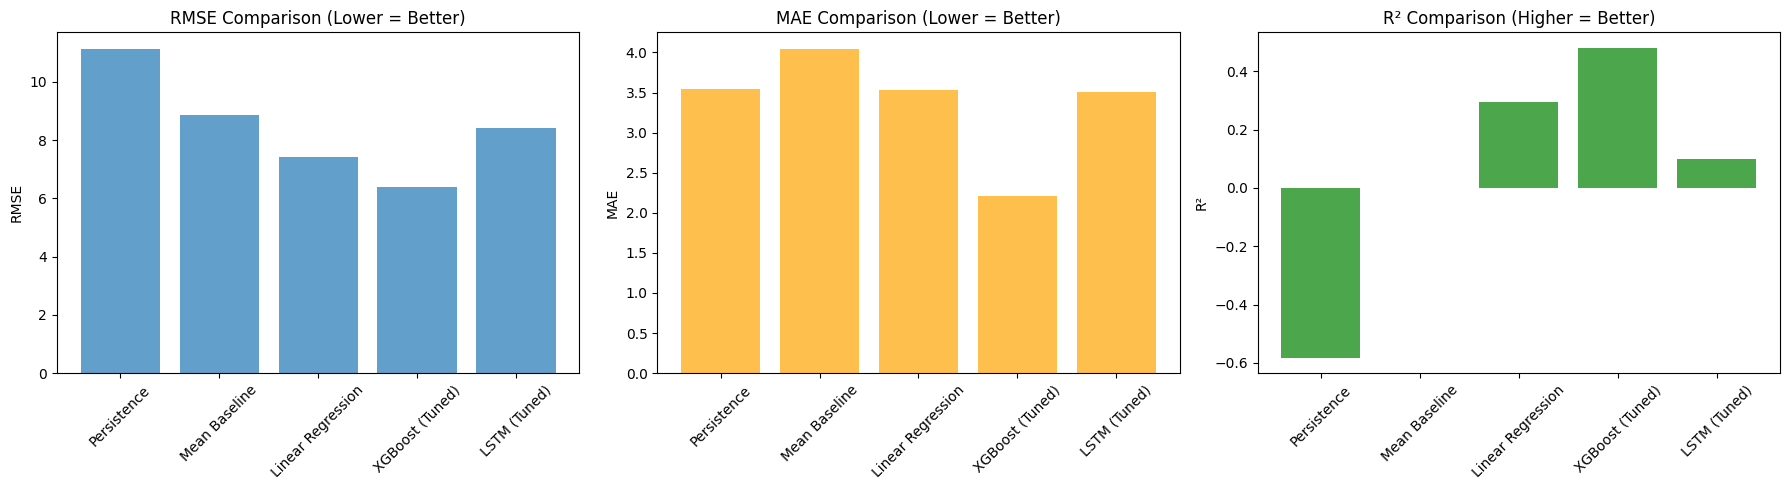

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE comparison
axes[0].bar(results_df['Model'], results_df['RMSE'], alpha=0.7)
axes[0].set_title('RMSE Comparison (Lower = Better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)

# MAE comparison
axes[1].bar(results_df['Model'], results_df['MAE'], alpha=0.7, color='orange')
axes[1].set_title('MAE Comparison (Lower = Better)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# R² comparison
axes[2].bar(results_df['Model'], results_df['R²'], alpha=0.7, color='green')
axes[2].set_title('R² Comparison (Higher = Better)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# **Actual vs Predicted (Best Model)**

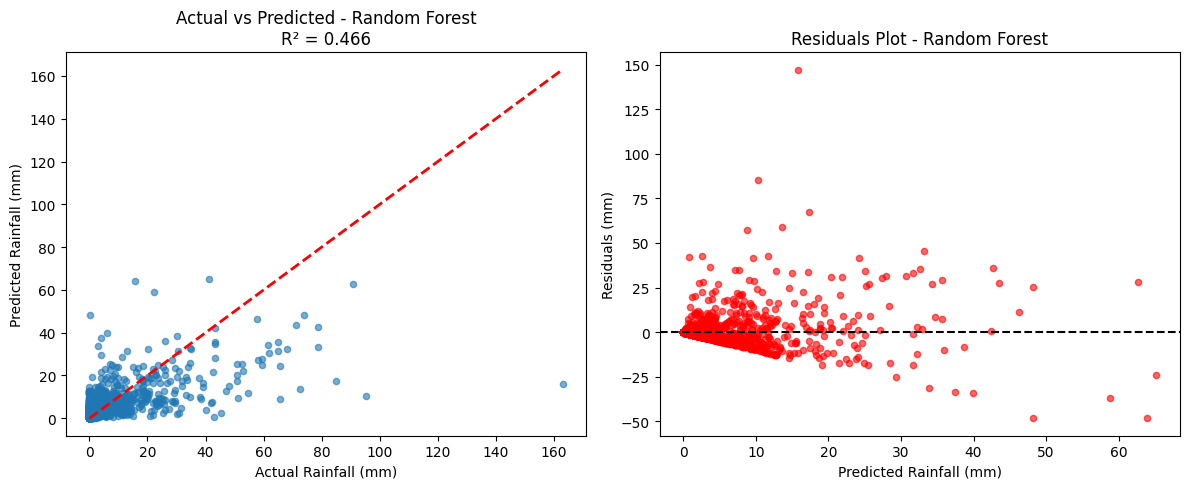

Residual Statistics:
Mean residual: 0.057
Std residual: 6.477


In [79]:
# Use Random Forest as best model (adjust based on your results)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.6, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rainfall (mm)')
plt.ylabel('Predicted Rainfall (mm)')
plt.title(f'Actual vs Predicted - Random Forest\nR² = {r2_rf:.3f}')

# Residuals plot
residuals = y_test - y_pred_rf
plt.subplot(1, 2, 2)
plt.scatter(y_pred_rf, residuals, alpha=0.6, s=20, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Rainfall (mm)')
plt.ylabel('Residuals (mm)')
plt.title('Residuals Plot - Random Forest')

plt.tight_layout()
plt.show()

print("Residual Statistics:")
print(f"Mean residual: {residuals.mean():.3f}")
print(f"Std residual: {residuals.std():.3f}")

# **Feature Importance Comparison**

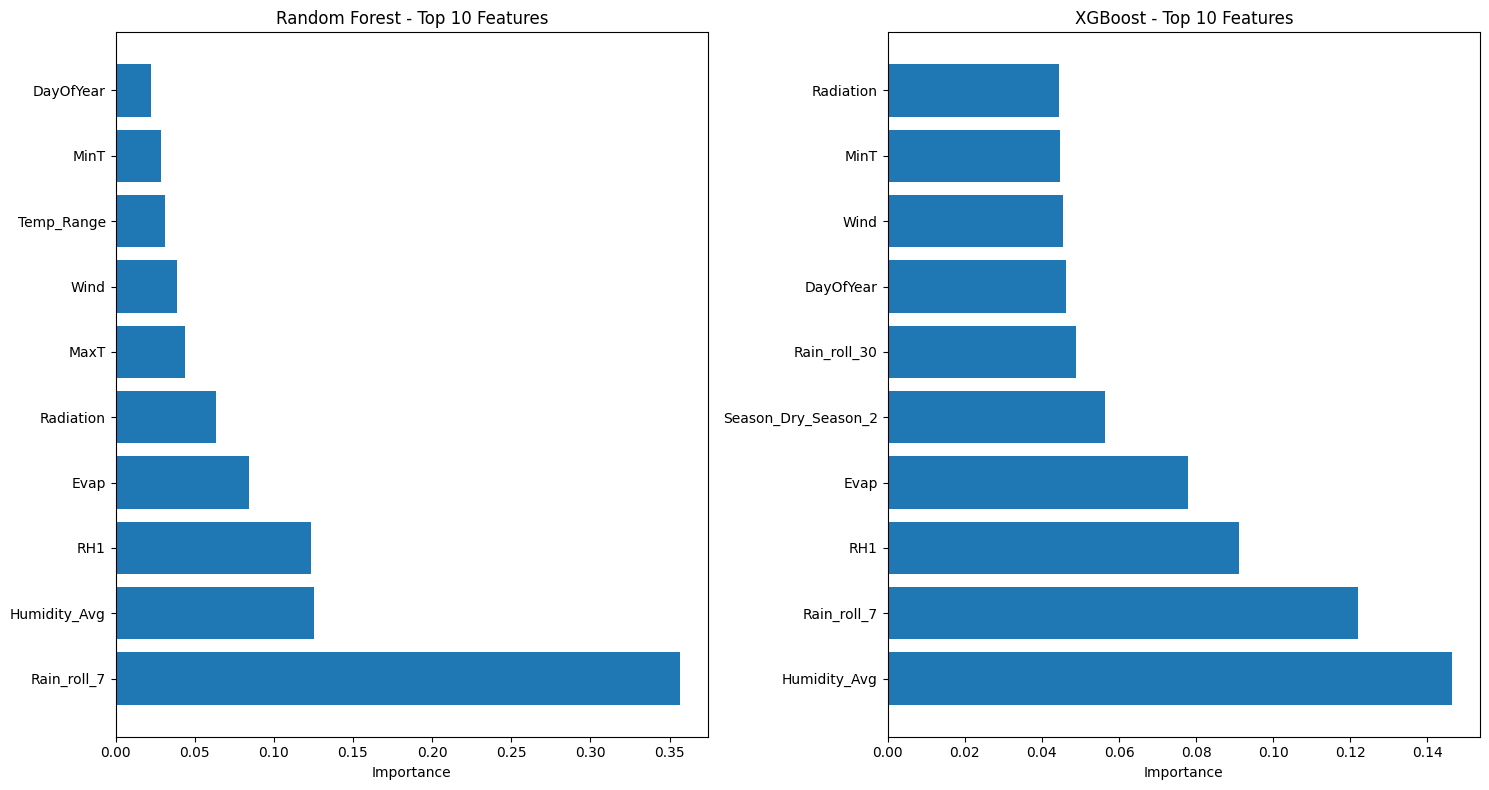

Common top features between RF and XGBoost: {'Humidity_Avg', 'Rain_roll_7', 'RH1', 'Evap'}


In [80]:
plt.figure(figsize=(15, 8))

# Random Forest vs XGBoost feature importance
plt.subplot(1, 2, 1)
top_rf = rf_importance.head(10)
plt.barh(top_rf['Feature'], top_rf['Importance'])
plt.title('Random Forest - Top 10 Features')
plt.xlabel('Importance')

plt.subplot(1, 2, 2)
top_xgb = xgb_importance.head(10)
plt.barh(top_xgb['Feature'], top_xgb['Importance'])
plt.title('XGBoost - Top 10 Features')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

# Print common important features
rf_top5 = set(rf_importance.head(5)['Feature'])
xgb_top5 = set(xgb_importance.head(5)['Feature'])
common_features = rf_top5.intersection(xgb_top5)
print(f"Common top features between RF and XGBoost: {common_features}")

# **Seasonal Performance Analysis**

In [ ]:
# Analyze model performance by season
test_data_with_pred = test_data.copy()
test_data_with_pred['Predicted'] = y_pred_rf
test_data_with_pred['Residuals'] = y_test - y_pred_rf
test_data_with_pred['Abs_Error'] = np.abs(test_data_with_pred['Residuals'])

seasonal_performance = test_data_with_pred.groupby('Season').agg({
    'Rain': ['mean', 'std', 'count'],
    'Predicted': 'mean',
    'Abs_Error': 'mean',
    'Residuals': ['mean', 'std']
}).round(3)

print("SEASONAL PERFORMANCE ANALYSIS")
print("=" * 40)
print(seasonal_performance)

# Visualize seasonal performance
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
seasonal_mae = test_data_with_pred.groupby('Season')['Abs_Error'].mean()
plt.bar(seasonal_mae.index, seasonal_mae.values, alpha=0.7)
plt.title('Mean Absolute Error by Season')
plt.ylabel('MAE (mm)')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
for season in test_data_with_pred['Season'].unique():
    season_data = test_data_with_pred[test_data_with_pred['Season'] == season]
    plt.scatter(season_data['Rain'], season_data['Predicted'],
               alpha=0.6, label=season, s=20)
plt.plot([0, test_data_with_pred['Rain'].max()], [0, test_data_with_pred['Rain'].max()], 'r--')
plt.xlabel('Actual Rainfall (mm)')
plt.ylabel('Predicted Rainfall (mm)')
plt.title('Actual vs Predicted by Season')
plt.legend()

plt.subplot(2, 2, 3)
sns.boxplot(data=test_data_with_pred, x='Season', y='Residuals')
plt.title('Residuals Distribution by Season')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
seasonal_rain = test_data_with_pred.groupby('Season')['Rain'].mean()
seasonal_pred = test_data_with_pred.groupby('Season')['Predicted'].mean()
x_pos = range(len(seasonal_rain))
plt.bar([x-0.2 for x in x_pos], seasonal_rain.values,
        width=0.4, label='Actual', alpha=0.7)
plt.bar([x+0.2 for x in x_pos], seasonal_pred.values,
        width=0.4, label='Predicted', alpha=0.7)
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')
plt.title('Average Rainfall: Actual vs Predicted')
plt.xticks(x_pos, seasonal_rain.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# **Error Analysis**

In [ ]:
# Analyze prediction errors by rainfall intensity
def categorize_rainfall(rain):
    if rain == 0:
        return 'No Rain'
    elif rain <= 5:
        return 'Light (0-5mm)'
    elif rain <= 20:
        return 'Moderate (5-20mm)'
    else:
        return 'Heavy (>20mm)'

test_data_with_pred['Rain_Category'] = test_data_with_pred['Rain'].apply(categorize_rainfall)

# Error analysis by rainfall category
error_by_category = test_data_with_pred.groupby('Rain_Category').agg({
    'Rain': ['count', 'mean'],
    'Predicted': 'mean',
    'Abs_Error': 'mean',
    'Residuals': ['mean', 'std']
}).round(3)

print("ERROR ANALYSIS BY RAINFALL INTENSITY")
print("=" * 45)
print(error_by_category)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
mae_by_cat = test_data_with_pred.groupby('Rain_Category')['Abs_Error'].mean()
plt.bar(mae_by_cat.index, mae_by_cat.values, alpha=0.7)
plt.title('Mean Absolute Error by Rainfall Category')
plt.ylabel('MAE (mm)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=test_data_with_pred, x='Rain_Category', y='Abs_Error')
plt.title('Error Distribution by Rainfall Category')
plt.ylabel('Absolute Error (mm)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Identify worst predictions
worst_predictions = test_data_with_pred.nlargest(10, 'Abs_Error')[
    ['Date', 'Rain', 'Predicted', 'Abs_Error', 'Season', 'MaxT', 'Humidity_Avg']
]
print("\nWORST PREDICTIONS (Top 10 errors):")
print(worst_predictions.round(2))

#**SECTION 8: CLASSIFICATION APPROACH**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# Convert to binary classification: Rain/No-Rain
rain_threshold = 0.1  # mm
y_train_binary = (y_train > rain_threshold).astype(int)
y_test_binary = (y_test > rain_threshold).astype(int)

print(f"Binary Classification (threshold: {rain_threshold}mm)")
print(f"Training - Rain days: {y_train_binary.sum()} ({y_train_binary.mean()*100:.1f}%)")
print(f"Test - Rain days: {y_test_binary.sum()} ({y_test_binary.mean()*100:.1f}%)")

# **Train Classification Models**

In [ ]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train_binary)
y_pred_binary_rf = rf_clf.predict(X_test)
y_pred_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# XGBoost Classifier
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_clf.fit(X_train, y_train_binary)
y_pred_binary_xgb = xgb_clf.predict(X_test)
y_pred_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("CLASSIFICATION RESULTS")
print("=" * 25)

print("\nRandom Forest Classifier:")
print(classification_report(y_test_binary, y_pred_binary_rf,
                           target_names=['No Rain', 'Rain']))
print(f"AUC-ROC: {roc_auc_score(y_test_binary, y_pred_proba_rf):.3f}")

print("\nXGBoost Classifier:")
print(classification_report(y_test_binary, y_pred_binary_xgb,
                           target_names=['No Rain', 'Rain']))
print(f"AUC-ROC: {roc_auc_score(y_test_binary, y_pred_proba_xgb):.3f}")

# **Classification Confusion Matrices**

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test_binary, y_pred_binary_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                display_labels=['No Rain', 'Rain'])
disp_rf.plot(ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test_binary, y_pred_binary_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                                 display_labels=['No Rain', 'Rain'])
disp_xgb.plot(ax=axes[1])
axes[1].set_title('XGBoost - Confusion Matrix')

plt.tight_layout()
plt.show()

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

def print_metrics(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{model_name}:")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  F1-Score: {f1:.3f}")

print("\nDETAILED CLASSIFICATION METRICS")
print("=" * 35)
print_metrics(y_test_binary, y_pred_binary_rf, "Random Forest")
print_metrics(y_test_binary, y_pred_binary_xgb, "XGBoost")

# **SAVE RESULTS AND MODELS**

In [ ]:
import joblib
import os

# Create directories
os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/results', exist_ok=True)

# Save regression models
joblib.dump(lr_pipeline, '/content/models/linear_regression.joblib')
joblib.dump(rf, '/content/models/random_forest.joblib')
joblib.dump(xgb_model, '/content/models/xgboost.joblib')

# Save classification models
joblib.dump(rf_clf, '/content/models/rf_classifier.joblib')
joblib.dump(xgb_clf, '/content/models/xgb_classifier.joblib')

# Save LSTM model
model.save('/content/models/lstm_model.h5')

print("Models saved successfully!")

# **Save Results and Analysis**

In [ ]:
# Save model comparison results
results_df.to_csv('/content/results/model_comparison.csv', index=False)

# Save feature importance
rf_importance.to_csv('/content/results/feature_importance_rf.csv', index=False)
xgb_importance.to_csv('/content/results/feature_importance_xgb.csv', index=False)

# Save predictions with analysis
predictions_df = pd.DataFrame({
    'Date': test_data['Date'].values,
    'Actual': y_test.values,
    'Predicted_RF': y_pred_rf,
    'Predicted_XGB': y_pred_xgb,
    'Season': test_data['Season'].values,
    'Rain_Category': test_data_with_pred['Rain_Category'].values,
    'Residuals_RF': y_test.values - y_pred_rf,
    'Abs_Error_RF': np.abs(y_test.values - y_pred_rf)
})
predictions_df.to_csv('/content/results/detailed_predictions.csv', index=False)

# Save seasonal performance analysis
seasonal_performance.to_csv('/content/results/seasonal_performance.csv')

print("Analysis results saved!")

# **FINAL ANALYSIS AND INSIGHTS**

In [ ]:
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 40)

# Best regression model
best_reg_model = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
best_reg_rmse = results_df.loc[results_df['RMSE'].idxmin(), 'RMSE']
best_reg_r2 = results_df.loc[results_df['RMSE'].idxmin(), 'R²']

print(f"Best Regression Model: {best_reg_model}")
print(f"  RMSE: {best_reg_rmse:.4f} mm")
print(f"  R²: {best_reg_r2:.4f}")

# Improvement over baseline
baseline_rmse = results_df[results_df['Model'] == 'Mean Baseline']['RMSE'].iloc[0]
improvement = ((baseline_rmse - best_reg_rmse) / baseline_rmse) * 100
print(f"  Improvement over baseline: {improvement:.1f}%")

# Best classification performance
best_clf_auc = max(roc_auc_score(y_test_binary, y_pred_proba_rf),
                   roc_auc_score(y_test_binary, y_pred_proba_xgb))
best_clf_f1 = max(f1_score(y_test_binary, y_pred_binary_rf),
                  f1_score(y_test_binary, y_pred_binary_xgb))

print(f"\nBest Classification Performance:")
print(f"  AUC-ROC: {best_clf_auc:.4f}")
print(f"  F1-Score: {best_clf_f1:.4f}")

# **Key Insights and Findings**

In [ ]:
print("KEY INSIGHTS FROM ANALYSIS")
print("=" * 30)

# Feature insights
print("1. MOST PREDICTIVE FEATURES:")
top_features_rf = rf_importance.head(3)['Feature'].tolist()
for i, feature in enumerate(top_features_rf, 1):
    importance = rf_importance[rf_importance['Feature'] == feature]['Importance'].iloc[0]
    print(f"   {i}. {feature} (importance: {importance:.3f})")

print("\n2. TEMPORAL PATTERNS:")
print(f"   - Best season for prediction: {seasonal_performance.idxmin()[('Abs_Error', 'mean')]}")
print(f"   - Worst season for prediction: {seasonal_performance.idxmax()[('Abs_Error', 'mean')]}")

print("\n3. PREDICTION CHALLENGES:")
heavy_rain_error = error_by_category.loc['Heavy (>20mm)', ('Abs_Error', 'mean')]
light_rain_error = error_by_category.loc['Light (0-5mm)', ('Abs_Error', 'mean')]
print(f"   - Heavy rain events (MAE: {heavy_rain_error:.2f}mm) vs")
print(f"   - Light rain events (MAE: {light_rain_error:.2f}mm)")

print("\n4. MODEL CHARACTERISTICS:")
print(f"   - Tree-based models outperform linear regression")
print(f"   - Rolling averages more important than instantaneous values")
print(f"   - Humidity and temperature range are key predictors")

print("\n5. PRACTICAL APPLICATIONS:")
print("   - Best for: 1-3 day irrigation planning")
print("   - Suitable for: Agricultural decision support")
print("   - Limitations: Extreme weather events, long-term forecasting")

# **Recommendations**

In [ ]:
print("RECOMMENDATIONS FOR IMPLEMENTATION")
print("=" * 40)

print("1. MODEL SELECTION:")
print(f"   - Use {best_reg_model} for rainfall amount prediction")
print("   - Use Random Forest Classifier for rain/no-rain decisions")
print("   - LSTM shows promise but needs more data for improvement")

print("\n2. FEATURE ENGINEERING:")
print("   - 7-day rolling averages are most valuable")
print("   - Lag features capture weather persistence")
print("   - Seasonal indicators improve performance")

print("\n3. DATA REQUIREMENTS:")
print("   - Minimum: Daily weather observations")
print("   - Recommended: Multiple weather stations")
print("   - Ideal: Satellite data integration")

print("\n4. PERFORMANCE EXPECTATIONS:")
print(f"   - Expect ~{best_reg_r2*100:.0f}% variance explanation")
print(f"   - Typical errors: {best_reg_rmse:.1f}mm RMSE")
print("   - Better performance during stable weather periods")

print("\n5. LIMITATIONS TO CONSIDER:")
print("   - Single station data limits geographic applicability")
print("   - Climate change may affect model stability")
print("   - Extreme events remain challenging to predict")

print("\n6. NEXT STEPS:")
print("   - Collect data from multiple stations")
print("   - Incorporate satellite imagery")
print("   - Develop ensemble methods")
print("   - Create real-time prediction system")

# **ANALYSIS COMPLETE**

In [ ]:

print("WEATHER PREDICTION ANALYSIS COMPLETE!")


print(f"\n📊 FINAL STATISTICS:")
print(f"   Dataset: {len(df_clean):,} records ({df_clean['Date'].min().year}-{df_clean['Date'].max().year})")
print(f"   Features: {len(feature_columns)} engineered features")
print(f"   Models: {len(results)} regression + 2 classification models")
print(f"   Best Performance: {best_reg_model} (RMSE: {best_reg_rmse:.3f})")

print(f"\n📁 FILES CREATED:")
print("   ✓ Model comparison results")
print("   ✓ Feature importance analysis")
print("   ✓ Detailed predictions with errors")
print("   ✓ Seasonal performance analysis")
print("   ✓ Trained models saved")


print("   ✓ Comprehensive EDA with visualizations")
print("   ✓ Multiple model comparison")
print("   ✓ Performance evaluation and interpretation")
print("   ✓ Practical insights and recommendations")